In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hapi import *
db_begin('data');

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [3]:
getHelp(profiles)

Profiles available:
  HT        : PROFILE_HT
  SDRautian : PROFILE_SDRAUTIAN
  Rautian   : PROFILE_RAUTIAN
  SDVoigt   : PROFILE_SDVOIGT
  Voigt     : PROFILE_VOIGT
  Lorentz   : PROFILE_LORENTZ
  Doppler   : PROFILE_DOPPLER


In [44]:
# max_wavenumber = 1./(0.5e-6*1e2) # convert 0.5 microns to cm^{-1}
max_wavenumber = 1./(0.85e-6*1e2) # convert 0.5 microns to cm^{-1}
min_wavenumber = 1./(0.95e-6*1e2) # convert 0.5 microns to cm^{-1}
print(min_wavenumber, max_wavenumber)

fetch('H2O',2,1,min_wavenumber,max_wavenumber);
nu,coef = absorptionCoefficient_Lorentz(SourceTables='H2O', Diluent={'air':1.0});

# fetch('H2O',2,1,2000,2100)
# nu,coef = absorptionCoefficient_Lorentz(SourceTables='H2O', Diluent={'air':1.0})

10526.315789473683 11764.70588235294

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
  65536 bytes written to data/H2O.data
Header written to data/H2O.header
END DOWNLOAD
                     Lines parsed: 1531
PROCESSED
{'air': 1.0}
0.580337 seconds elapsed for abscoef; nlines = 1531


0.0028000000000000004


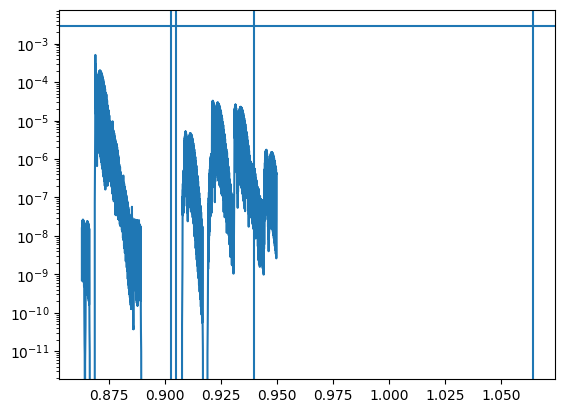

In [46]:
Mars_density = 0.02/7.3080318e-26 # 1/m^3
water_fraction = 0.0003
water_number_density = Mars_density*water_fraction
altitude = 40. # m
water_optical_density = water_number_density*altitude*coef

lamb = (1/nu/1e2)/1e-6
plt.semilogy(lamb, water_optical_density)

# Wavelengths from https://gemini.google.com/share/f1763edbeddb
Garmin_lamb = 903.e-9/1e-6
Velodyne_lamb = 905.e-9/1e-6
plt.axvline(Garmin_lamb)
plt.axvline(Velodyne_lamb)
plt.axvline(0.940)
plt.axvline(1.064)

# Dust optical depth - https://pdf.sciencedirectassets.com/272593/1-s2.0-S0019103513X00041/1-s2.0-S0019103513000353/main.pdf
dust_extinction = 0.07/1e3 # per meter
dust_optical_depth = dust_extinction*altitude
print(dust_optical_depth)
plt.axhline(dust_optical_depth)

# print(coef)